## Manipulation of hysteresis loops

This tutorial will provide a few examples for automated data correction/manipulation of (magnetic) hysteresis loops possible with evaluix. These are
1. invert the field and/or magnetization axis
2. Automatic detection and deletion of outliers
3. Smoothing the hysteresis curve with different filters
4. Remove hysteresis opening in saturation
5. Remove common slopes in saturation, i.e. dia- or paramagnetic-like trends
6. Center and eventually normalize the hysteresis loop 

It is recommended to apply the manipulations in the order above, leaving out unnessecary steps. The manipulations ``del_outliers()``, ``rmv_opening()`` and ``slope_correction()`` compare the possibly removed effects with the noise level of the hysteresis loop and are only applied above certain thresholds, which enables their potential usage in automated processes. Nevertheless, all data manipulation steps should be performed with caution.

This tutorial first shows the combined manipulation of ``del_outliers()``, ``rmv_opening()``, ``slope_correction()`` and ``hys_norm()`` before it treats all of the manipulations in the list individually.

### Combined correction and their order
In the following a simulated hysteresis loop based on a Stoner-Wohlfahrt-approach with an exchange bias field of H<sub>EB</sub> = -60 and a coercive field strength of about H<sub>C</sub> = 45 is loaded. The simulation has been heavily modified to introduce the effects which should be corrected by the manipulation methods here.

   Applied Field (H [arb. u.])  Magnetization with slope
0                        200.0                  4.502451
1                        199.0                  4.554659
2                        198.0                  4.511292
3                        197.0                  4.504445
4                        196.0                  4.463541


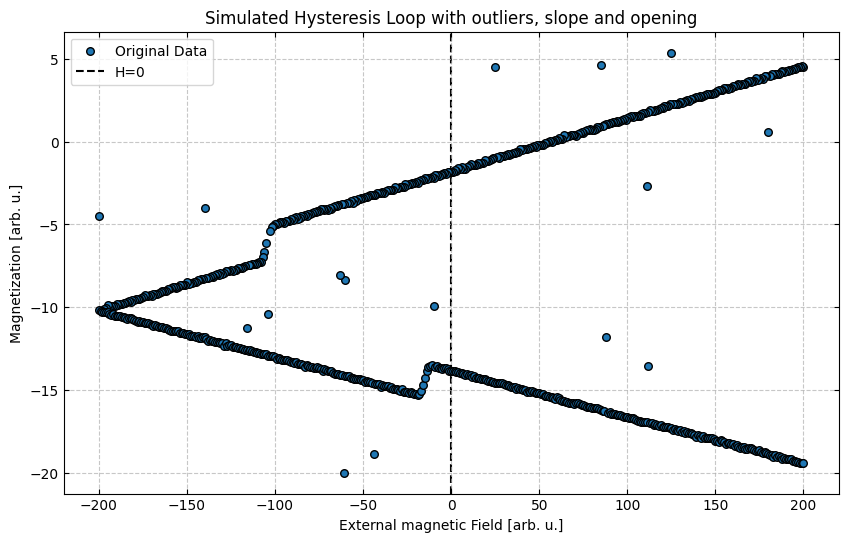

In [15]:
from pathlib import Path
import pandas as pd

csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_all.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(fields, magnetization, label='Original Data', edgecolor='k', s=30, zorder=5)
plt.title('Simulated Hysteresis Loop with outliers, slope and opening')
plt.xlabel('External magnetic Field [arb. u.]')
plt.ylabel('Magnetization [arb. u.]')
plt.tick_params(direction='in', top=True, right=True)
plt.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
plt.axvline(0, color='k', linestyle='--', label='H=0', zorder=1)
plt.legend()
plt.show()

If such a hysteresis is measured, the best practice would be to repeat the measurement in question. However, there are occurences where this is not possible or very time consuming, for example when the sample has been modified/destroyed or strong training effects are present. For such cases, the following procedure has been created to enable teh evaluation of such hysteresis curves. Nevertheless, modifications of data should always be performed with caution. 

__Note:__ At the end of this tutorial, there are a few notes about magnetic effects which may be modified or even compensated by these manipulation functions 

The order of manipulations is important! 
- Outliers affect the calculation of the trends for the other manipulations and should be removed first, although it is more difficult with other trends present.
- The opening is a trend in time/point number. Calculating the trend in time is (ideally) independent from trends in the field and should be compensated first. Otherwise, the trends in the fields are overlapped by them.
- Normalization assumes that the outermost part (typ. 5% but can be selected) is in saturation and normalizes everything to thes values. Therefore, the saturated part should be a horizontal line and all other effects should be compensated before.

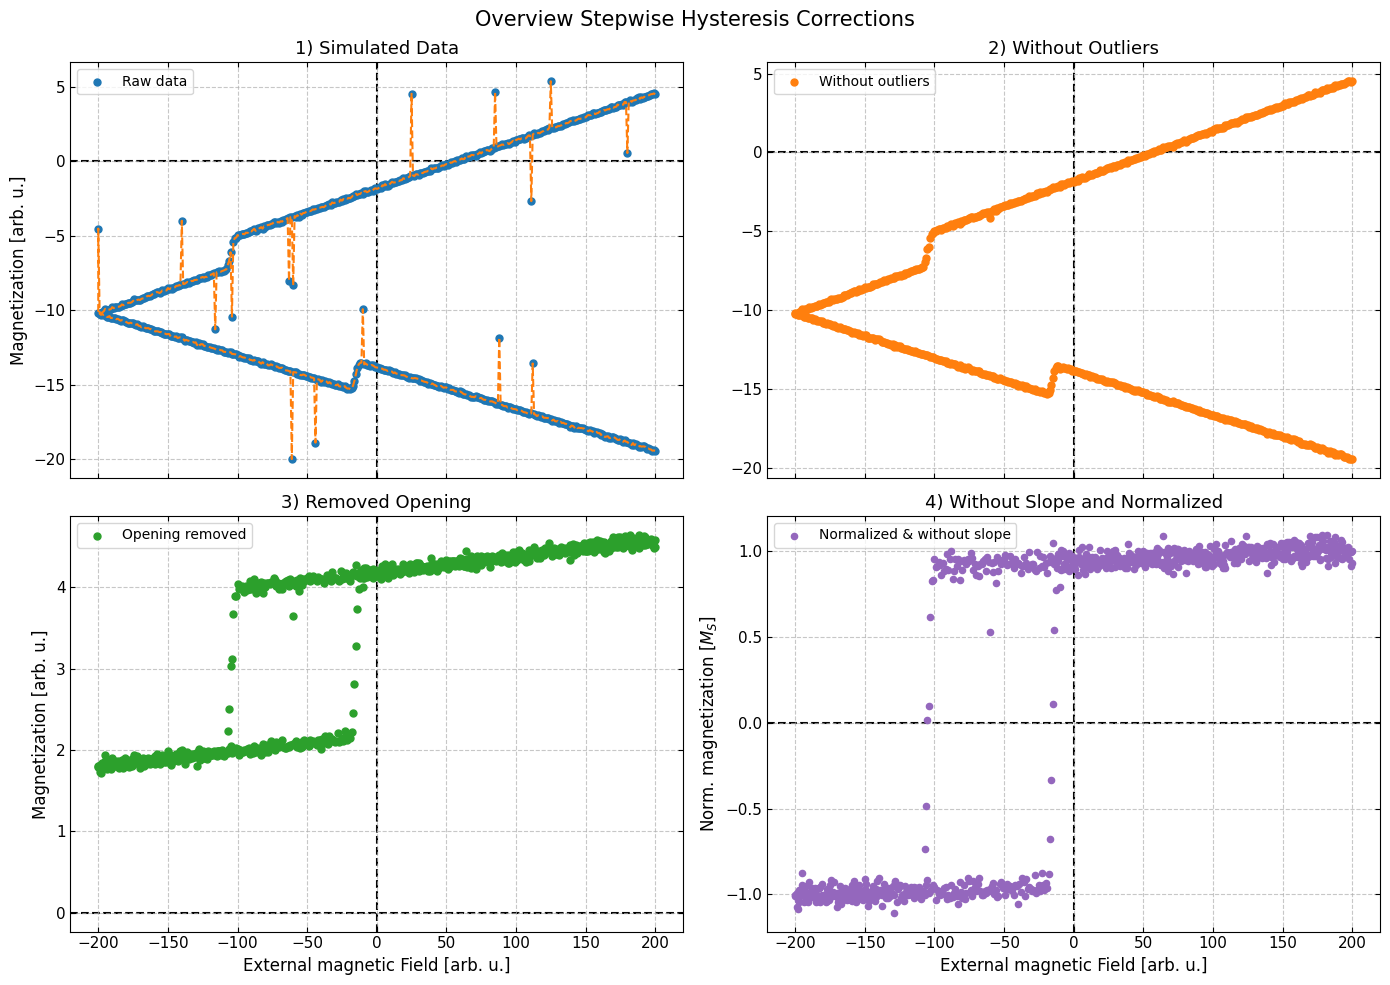

In [50]:
from evaluix.utils import HysteresisFunctions as hf

# Keep original data unchanged
raw_data = magnetization.copy()

# 1. Remove outliers
without_outliers = hf.del_outliers(raw_data.copy())

# 2. Remove opening at saturation
removed_opening = hf.rmv_opening(without_outliers.copy())

# 3. Remove slope at saturation
without_slope = hf.slope_correction(fields, removed_opening.copy())

# 4. Normalize magnetization
normalized_without_slope = hf.hys_norm(fields, without_slope.copy())

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
fontsize = 12

# Panel 1: Raw data
ax = axes[0, 0]
ax.scatter(fields, raw_data, color='tab:blue', s=25, zorder=5, label='Raw data')
ax.plot(fields, raw_data, color='tab:orange', linestyle='--', zorder=6)
ax.set_title('1) Simulated Data', fontsize=fontsize + 1)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)
ax.tick_params(direction='in', top=True, right=True, labelsize=fontsize - 1)
ax.legend(fontsize=fontsize - 2, loc='best')

# Panel 2: Without outliers
ax = axes[0, 1]
ax.scatter(fields, without_outliers, color='tab:orange', s=25, zorder=5, label='Without outliers')
ax.set_title('2) Without Outliers', fontsize=fontsize + 1)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)
ax.tick_params(direction='in', top=True, right=True, labelsize=fontsize - 1)
ax.legend(fontsize=fontsize - 2, loc='best')

# Panel 3: Removed opening
ax = axes[1, 0]
ax.scatter(fields, removed_opening, color='tab:green', s=25, zorder=5, label='Opening removed')
ax.set_title('3) Removed Opening', fontsize=fontsize + 1)
ax.set_xlabel('External magnetic Field [arb. u.]', fontsize=fontsize)
ax.set_ylabel('Magnetization [arb. u.]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)
ax.tick_params(direction='in', top=True, right=True, labelsize=fontsize - 1)
ax.legend(fontsize=fontsize - 2, loc='best')

# Panel 4: Last two steps (slope correction + normalization) in one plot
ax = axes[1, 1]
ax.scatter(fields, normalized_without_slope, color='tab:purple', s=20, zorder=6, label='Normalized & without slope')
ax.set_title('4) Without Slope and Normalized', fontsize=fontsize + 1)
ax.set_xlabel('External magnetic Field [arb. u.]', fontsize=fontsize)
ax.set_ylabel('Norm. magnetization [$M_S$]', fontsize=fontsize)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)
ax.tick_params(direction='in', top=True, right=True, labelsize=fontsize - 1)
ax.legend(fontsize=fontsize - 2, loc='best')

plt.suptitle('Overview Stepwise Hysteresis Corrections', fontsize=fontsize + 3)
plt.tight_layout()
plt.show()

### Delete Outliers

Outliers are individual points where something went wrong during the measurement. The most prominent case in our instruments is the LMOKE where sometimes, a timing mismatch between the detector and the Ni-Box can occur, leading to one or two single points per hysteresis with a way higher or lower intensity. As outliers will affect the data manipulation of the other manipulation steps as well as the analysis (covered in __HysteresisDataEvaluation__), it is recommended to get rid of them, either by remeasuring the curve (if reasonable) or by applying the ``del_outliers()`` function of Evaluix.

As the name implies, outliers drastically differ from their expected value. As the expected value is often unknown in experiments, it is approximated by the points in close vicinity. So, for each point in _ydata_, the function ``del_outliers(ydata, threshold, neighbours)`` compares the difference to the mean of its _&plusmn;neighbours_ with the mean of absolute differences (mad) of the same neighbours. If the difference exceeds the mad, weighted by the _threshold_, the point is considered as an outlier. Thus, each point is compared to the local noise level (or data spread) in order to determine whether it is an outlier or not. If the point was identified as an outlier, it is replaced by the mean of the _&plusmn;neighbours_ as a simple interpolation.

   Applied Field (H [arb. u.])  Magnetization with slope
0                        200.0                  4.102451
1                        199.0                  4.186659
2                        198.0                  4.175292
3                        197.0                  4.200445
4                        196.0                  4.191541


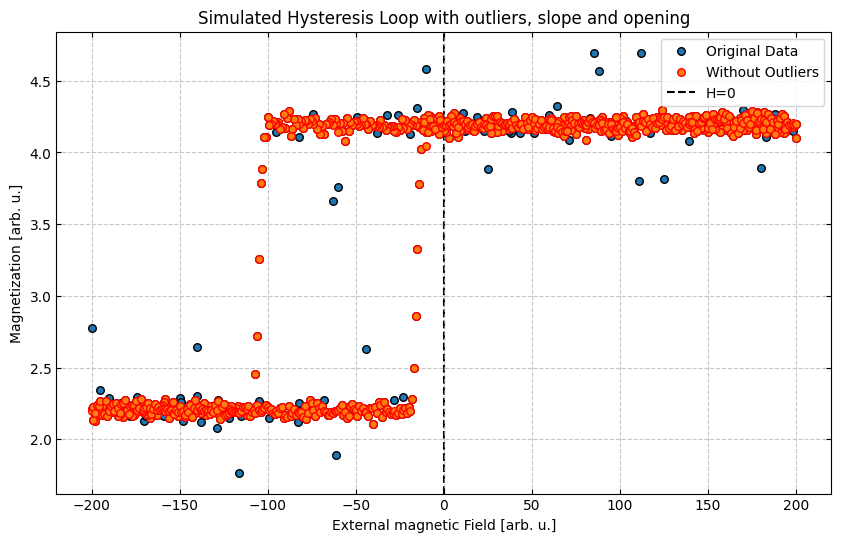

In [51]:

csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_outliers.csv"
data = pd.read_csv(csv_path)

print(data.head())

fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

# Remove outliers
without_outliers = hf.del_outliers(magnetization.copy())

plt.figure(figsize=(10, 6))
plt.scatter(fields, magnetization, label='Original Data', edgecolor='k', s=30, zorder=5)
plt.scatter(fields, without_outliers, label='Without Outliers', edgecolor='r', s=30, zorder=5)
plt.title('Simulated Hysteresis Loop with outliers, slope and opening')
plt.xlabel('External magnetic Field [arb. u.]')
plt.ylabel('Magnetization [arb. u.]')
plt.tick_params(direction='in', top=True, right=True)
plt.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
plt.axvline(0, color='k', linestyle='--', label='H=0', zorder=1)
plt.legend()
plt.show()


In [59]:
from typing import Union
import numpy as np

def del_outliers(
    ydata: Union[list, pd.DataFrame, pd.Series, np.ndarray],
    threshold: float = 2.0,
    neighbours: int = 5,
    return_details: bool = False,
 ):
    """
    Remove outliers and optionally report which detection condition flagged each point.

    Detection is based on robust global and local scores (median/MAD), which
    are less sensitive to existing spikes than mean-based statistics.

    Conditions
    ----------
    cond_1 : global + local consistency check
        global_score > threshold and local_score > 0.5 * threshold
    cond_2 : strict local check
        local_score > threshold
    """
    if not isinstance(ydata, (list, pd.DataFrame, pd.Series, np.ndarray)):
        raise ValueError(f"ydata must be a pandas dataframe, list or numpy array, not {type(ydata)}")

    y = np.asarray(ydata, dtype=float).copy()
    n = len(y)

    if n == 0:
        if return_details:
            empty = np.array([], dtype=int)
            details = {
                "cond_1": np.array([], dtype=bool),
                "cond_2": np.array([], dtype=bool),
                "both": np.array([], dtype=bool),
                "only_cond_1": np.array([], dtype=bool),
                "only_cond_2": np.array([], dtype=bool),
                "outliers": np.array([], dtype=bool),
                "indices_cond_1": empty,
                "indices_cond_2": empty,
                "indices_both": empty,
                "indices_only_cond_1": empty,
                "indices_only_cond_2": empty,
                "indices_outliers": empty,
            }
            return y, details
        return y

    # Robust global statistics
    med_all = np.median(y)
    mad_all = np.median(np.abs(y - med_all))

    # A small adaptive floor avoids division-by-zero / unstable scores on flat data
    eps_scale = np.median(np.abs(np.diff(y))) if n > 1 else 0.0
    scale_floor = max(1e-12, 0.1 * eps_scale)

    # Convert MAD to robust sigma-like scale (1.4826 factor)
    sigma_all = max(1.4826 * mad_all, scale_floor)

    # Local robust statistics
    med_neigh = np.zeros_like(y)
    sigma_neigh = np.zeros_like(y)

    for i in range(n):
        start = max(0, i - neighbours)
        end = min(n, i + neighbours + 1)
        neigh_slice = y[start:end]

        med_i = np.median(neigh_slice)
        mad_i = np.median(np.abs(neigh_slice - med_i))

        med_neigh[i] = med_i
        sigma_neigh[i] = max(1.4826 * mad_i, scale_floor)

    global_score = np.abs(y - med_all) / sigma_all
    local_score = np.abs(y - med_neigh) / sigma_neigh

    cond_1 = (global_score > threshold) & (local_score > 0.5 * threshold)
    cond_2 = local_score > threshold

    outliers = cond_1 | cond_2
    outlier_indices = np.where(outliers)[0]

    # Replace outliers with local interpolation (mean of neighbours excluding the outlier)
    for outlier in outlier_indices:
        if outlier:
            start = max(0, outlier - neighbours)
            end = min(outlier + neighbours + 1, n)
            neigh_slice = np.concatenate([y[start:outlier], y[outlier + 1:end]])
            if len(neigh_slice):
                y[outlier] = np.mean(neigh_slice)

    if return_details:
        details = {
            "cond_1": cond_1,
            "cond_2": cond_2,
            "both": cond_1 & cond_2,
            "only_cond_1": cond_1 & ~cond_2,
            "only_cond_2": cond_2 & ~cond_1,
            "outliers": outliers,
            "indices_cond_1": np.where(cond_1)[0],
            "indices_cond_2": np.where(cond_2)[0],
            "indices_both": np.where(cond_1 & cond_2)[0],
            "indices_only_cond_1": np.where(cond_1 & ~cond_2)[0],
            "indices_only_cond_2": np.where(cond_2 & ~cond_1)[0],
            "indices_outliers": outlier_indices,
            "global_score": global_score,
            "local_score": local_score,
        }
        return y, details

    return y


Threshold: 2.0


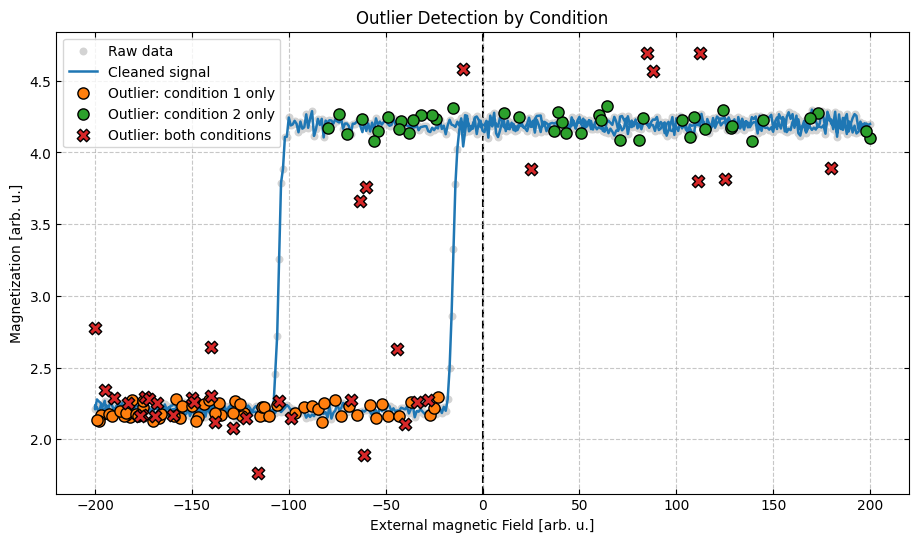

Condition 1 only indices: [312 323 324 329 335 336 338 344 347 356 358 367 370 375 382 384 385 397
 398 399 408 410 414 417 420 422 423 426 435 442 446 451 453 460 473 476
 486 487 488 491 495 504 509 513 516 518 519 525 528 532 536 543 546 549
 552 558 564 574 576 578]
Condition 2 only indices: [  0  27  31  55  76  85  91  93 119 129 136 149 159 161 181 189 215 224
 226 232 236 238 242 243 249 254 256 262 270 274 280 638 644 661 662 684
 704 729 730 740 799]
Both conditions indices: [ 20  75  89 115 175 260 263 316 322 340 350 374 376 377 383 390 395 401
 429 432 433 441 452 461 463 472 496 502 533 540 557 561 567 573 591 689
 713]

Threshold: 2.1


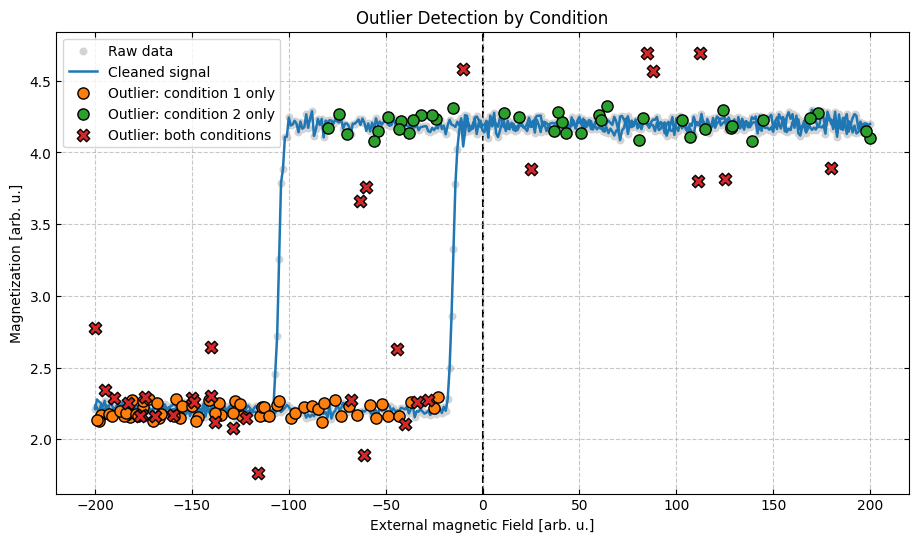

Condition 1 only indices: [312 324 329 335 336 338 347 356 358 367 370 375 382 384 385 397 398 399
 408 410 414 417 420 422 423 426 429 433 435 442 446 451 453 460 473 476
 486 487 488 491 495 496 502 504 509 513 516 518 519 525 528 532 536 543
 546 549 552 558 564 576 578]
Condition 2 only indices: [  0  27  31  55  76  85  93 119 136 149 159 161 181 189 215 224 226 232
 236 238 242 243 249 254 256 270 274 280 638 644 661 662 684 704 729 730
 740 799]
Both conditions indices: [ 20  75  89 115 175 260 263 316 322 340 350 374 376 377 383 390 395 401
 432 441 452 461 463 472 533 540 557 561 567 573 591 689 713]

Threshold: 2.2


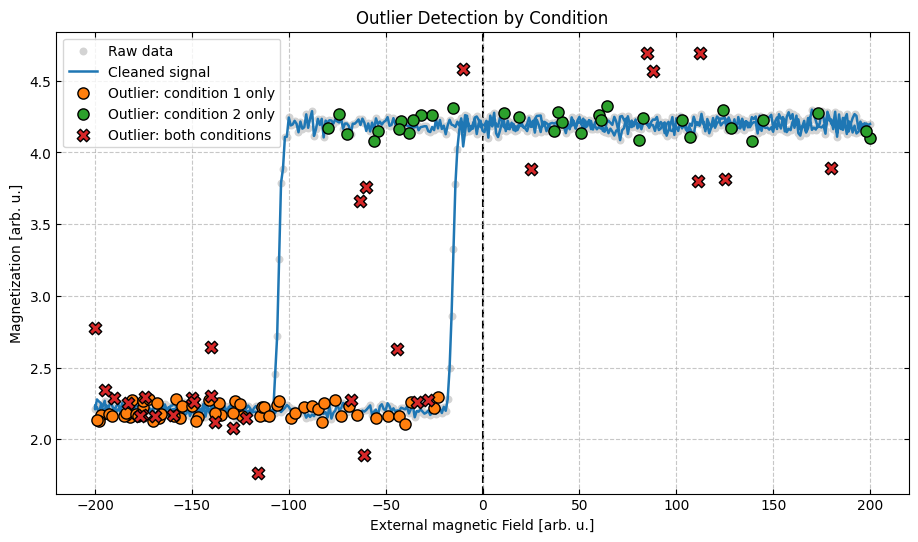

Condition 1 only indices: [312 324 329 335 336 338 347 356 358 367 370 375 382 384 385 397 398 399
 408 410 417 420 422 423 426 429 433 435 442 446 451 453 460 473 476 486
 487 488 491 495 496 502 504 509 513 516 518 519 525 528 532 536 546 552
 558 561 564 576 578]
Condition 2 only indices: [  0  27  55  76  93 119 136 149 159 161 181 189 215 226 232 236 238 242
 243 254 256 270 274 280 638 661 662 684 704 729 740 799]
Both conditions indices: [ 20  75  89 115 175 260 263 316 322 340 350 374 376 377 383 390 395 401
 432 441 452 461 463 472 533 540 557 567 573 591 689 713]

Threshold: 2.3000000000000003


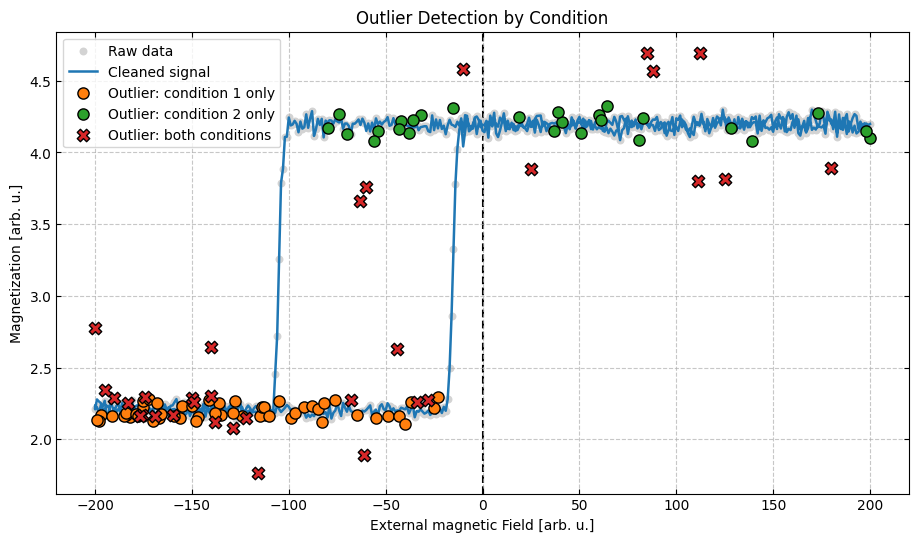

Condition 1 only indices: [312 324 329 335 336 338 347 356 367 370 375 382 384 385 397 398 399 410
 417 422 423 426 429 433 435 442 446 451 453 460 473 486 487 488 491 496
 502 504 509 513 516 518 519 525 536 546 552 558 561 564 576 578]
Condition 2 only indices: [  0  27 119 136 149 159 161 181 215 232 236 238 242 243 254 256 270 274
 280 638 661 662 684 729 740 799]
Both conditions indices: [ 20  75  89 115 175 260 263 316 322 340 350 374 376 377 383 390 395 401
 432 441 452 461 463 472 533 540 557 567 573 591 689 713]

Threshold: 2.4000000000000004


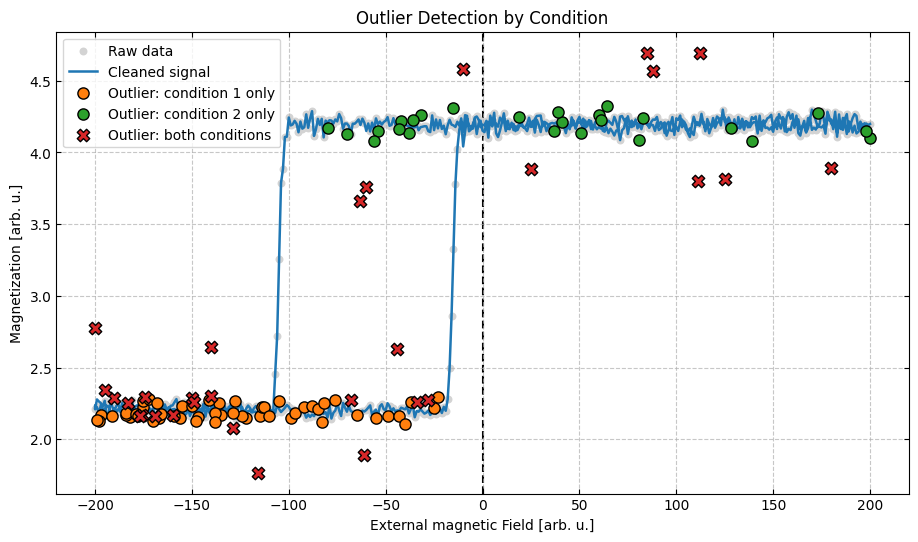

Condition 1 only indices: [322 324 329 335 336 338 347 356 367 370 375 382 384 397 398 399 410 417
 422 423 426 429 433 435 442 446 451 453 460 463 473 486 487 488 491 496
 502 504 509 513 516 518 519 525 536 546 552 558 561 564 576 578]
Condition 2 only indices: [  0  27 119 136 149 159 161 181 215 232 236 238 242 243 254 256 270 280
 638 661 662 684 729 740 799]
Both conditions indices: [ 20  75  89 115 175 260 263 316 340 350 374 376 377 383 390 395 401 432
 441 452 461 472 533 540 557 567 573 591 689 713]


In [60]:
# Show which condition detected each outlier
cleaned_list = []
details_list = []
thresh_list = np.arange(2, 2.5, 0.1)
for thresh in thresh_list:
    cleaned, details = del_outliers(magnetization.copy(), return_details=True, threshold=thresh)
    cleaned_list.append(cleaned)
    details_list.append(details)

for thresh, cleaned, details in zip(thresh_list, cleaned_list, details_list):
    print(f"\nThreshold: {thresh}")
    idx_c1 = details["indices_only_cond_1"]
    idx_c2 = details["indices_only_cond_2"]
    idx_both = details["indices_both"]

    plt.figure(figsize=(11, 6))
    plt.scatter(fields, magnetization, s=22, c="lightgray", label="Raw data", zorder=1)
    plt.plot(fields, cleaned, c="tab:blue", lw=1.8, label="Cleaned signal", zorder=2)

    if len(idx_c1):
        plt.scatter(fields[idx_c1], magnetization[idx_c1], s=65, c="tab:orange", edgecolor="k",
                    label="Outlier: condition 1 only", zorder=3)
    if len(idx_c2):
        plt.scatter(fields[idx_c2], magnetization[idx_c2], s=65, c="tab:green", edgecolor="k",
                    label="Outlier: condition 2 only", zorder=3)
    if len(idx_both):
        plt.scatter(fields[idx_both], magnetization[idx_both], s=80, c="tab:red", marker="X", edgecolor="k",
                    label="Outlier: both conditions", zorder=4)

    plt.title("Outlier Detection by Condition")
    plt.xlabel("External magnetic Field [arb. u.]")
    plt.ylabel("Magnetization [arb. u.]")
    plt.grid(which="both", linestyle="--", alpha=0.7, zorder=0)
    plt.axvline(0, color="k", linestyle="--", zorder=0)
    plt.tick_params(direction="in", top=True, right=True)
    plt.legend()
    plt.show()

    print("Condition 1 only indices:", idx_c1)
    print("Condition 2 only indices:", idx_c2)
    print("Both conditions indices:", idx_both)